In [1]:
from typing import List
from pathlib import Path
import pickle

from PIL import Image, ImageOps
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

from detectron2.data import DatasetCatalog
from detectron2.utils.visualizer import Visualizer, ColorMode

/home/abhinavchadaga/CS/fri_II/.venv/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_to_dataset = "./dataset/annotated_building_imgs/"
dataset_name = "annotated elevator images"

In [3]:
def register_dataset():
    """ Define function to register our custom dataset
    """
    dataset = list()
    for building in Path(path_to_dataset).iterdir():
        for img in building.iterdir():
            img_dict = pickle.load(open(img.as_posix(), 'rb'))            
            dataset.append(img_dict)
    return dataset

In [4]:
DatasetCatalog.register(dataset_name, register_dataset)
dataset: List[dict] = DatasetCatalog.get(dataset_name)

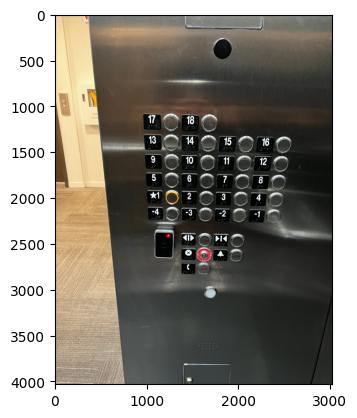

In [7]:
import random


idx = random.randint(0, len(dataset))

img_dict = dataset[idx]
img = Image.open(img_dict['file_name'])
img = ImageOps.exif_transpose(img)
plt.imshow(img)

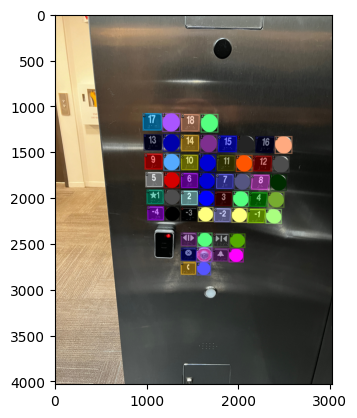

In [8]:
v = Visualizer(img_rgb=img, instance_mode=ColorMode.IMAGE)
annotations = v.draw_dataset_dict(dic=img_dict).get_image()
plt.imshow(annotations)